# Notebook 08 - Image-Only Baseline ViT/CLIP

Notebook ini melatih baseline **image-only** untuk MABSA hotel review.

Tahap ini hanya memakai gambar dan label image dari Notebook 06. Teks tidak dipakai sebagai input.

Tujuan:

1. Mengukur seberapa kuat sinyal visual sendiri untuk 7 aspek hotel.
2. Menjadi pembanding untuk Notebook 09 `late_fusion_multimodal_baseline`.
3. Menjadi dasar analisis image-only aspect, terutama aspek visual seperti Kamar, Kebersihan, Lokasi, Fasilitas, dan Makanan.

Strategi baseline:

- Frozen CLIP/ViT visual encoder.
- Ekstraksi embedding gambar sekali dan simpan sebagai cache.
- Train classifier head multi-aspect di atas embedding.

Catatan penting:

Notebook ini memprediksi **label image** (`label_image_*`), bukan label teks. Jadi skor Notebook 08 tidak boleh dibaca sebagai pengganti skor text-only Notebook 07, melainkan sebagai ukuran kekuatan visual modality.

## Dasar Metodologis

Notebook ini mengikuti best practice transfer learning visual:

1. **CLIP sebagai visual representation learner.** CLIP dilatih dengan natural language supervision pada pasangan image-text skala besar, sehingga representasi visualnya kuat untuk transfer ke downstream tasks. Ini cocok untuk baseline image-only pada dataset review hotel.

2. **ViT/CLIP memakai patch-based image encoding.** Vision Transformer memproses gambar sebagai rangkaian patch, sehingga input harus dipreprocess konsisten dengan konfigurasi pretrained model.

3. **Linear probing sebelum full fine-tuning.** Untuk baseline awal, frozen encoder + classifier head lebih stabil, hemat VRAM, dan lebih mudah dijelaskan. Jika baseline ini sudah terbentuk, fine-tuning penuh bisa menjadi eksperimen lanjutan, bukan baseline pertama.

4. **Image-only MABSA perlu label image.** Karena data kamu memiliki label visual per aspek, Notebook 08 mengevaluasi kemampuan gambar untuk mengenali aspek/sentimen visual. Ini membantu menjawab kasus `image-only aspect`.

5. **Imbalance tetap ditangani.** Label image juga banyak `None`, sehingga classifier head memakai dampened class weight dan macro-F1 menjadi metric utama.

Referensi:

- Radford et al. (2021), *Learning Transferable Visual Models From Natural Language Supervision*. https://proceedings.mlr.press/v139/radford21a.html
- Dosovitskiy et al. (2021), *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale*. https://arxiv.org/abs/2010.11929
- Kumar et al. (2022), *Fine-tuning can distort pretrained features and underperform out-of-distribution*. https://arxiv.org/abs/2202.10054
- Cui et al. (2019), *Class-Balanced Loss Based on Effective Number of Samples*. https://openaccess.thecvf.com/content_CVPR_2019/html/Cui_Class-Balanced_Loss_Based_on_Effective_Number_of_Samples_CVPR_2019_paper.html

### 1. Import Library dan Modul Dependensi


In [1]:
# Tahap: Import Library dan Modul

from pathlib import Path
import json
import math
import os
import random
import shutil
import subprocess
import sys
import time
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image, ImageOps

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 180)

SEED = 42
IMAGE_MODEL_NAME = os.environ.get("IMAGE_MODEL_NAME", "openai/clip-vit-base-patch32")

EXTRACT_BATCH_SIZE = int(os.environ.get("IMAGE_EXTRACT_BATCH_SIZE", "64"))
HEAD_BATCH_SIZE = int(os.environ.get("IMAGE_HEAD_BATCH_SIZE", "256"))
HEAD_EPOCHS = int(os.environ.get("IMAGE_HEAD_EPOCHS", "30"))
HEAD_LR = float(os.environ.get("IMAGE_HEAD_LR", "1e-3"))
HEAD_WEIGHT_DECAY = float(os.environ.get("IMAGE_HEAD_WEIGHT_DECAY", "1e-4"))
HEAD_DROPOUT = float(os.environ.get("IMAGE_HEAD_DROPOUT", "0.25"))
HEAD_PATIENCE = int(os.environ.get("IMAGE_HEAD_EARLY_STOPPING_PATIENCE", "5"))
MAX_GRAD_NORM = float(os.environ.get("IMAGE_HEAD_MAX_GRAD_NORM", "1.0"))

USE_CLASS_WEIGHTS = os.environ.get("IMAGE_USE_CLASS_WEIGHTS", "1") == "1"
CLASS_WEIGHT_POWER = float(os.environ.get("IMAGE_CLASS_WEIGHT_POWER", "0.5"))
CLASS_WEIGHT_CLIP_MAX = float(os.environ.get("IMAGE_CLASS_WEIGHT_CLIP_MAX", "10.0"))
NORMALIZE_FEATURES = os.environ.get("IMAGE_NORMALIZE_FEATURES", "1") == "1"
USE_AMP = os.environ.get("IMAGE_USE_AMP", "1") == "1"
NUM_WORKERS = int(os.environ.get("IMAGE_NUM_WORKERS", "2"))

ASPECTS = ["Kamar", "Kebersihan", "Pelayanan", "Harga", "Lokasi", "Fasilitas", "Makanan"]
LABEL_ORDER = ["None", "Negatif", "Netral", "Positif"]
LABEL_TO_ID = {"None": 0, "Negatif": 1, "Netral": 2, "Positif": 3}
ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}
SPLIT_TO_ID = {"train": 0, "val": 1, "test": 2}
ID_TO_SPLIT = {v: k for k, v in SPLIT_TO_ID.items()}

IS_KAGGLE = Path("/kaggle").exists()
OUTPUT_DIR = Path("/kaggle/working/mabsa_image_only_clip_baseline_outputs") if IS_KAGGLE else Path("mabsa_image_only_clip_baseline_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("Kaggle environment:", IS_KAGGLE)
print("Image model:", IMAGE_MODEL_NAME)
print("Extract batch size:", EXTRACT_BATCH_SIZE)
print("Head epochs:", HEAD_EPOCHS)
print("Head batch size:", HEAD_BATCH_SIZE)
print("Use class weights:", USE_CLASS_WEIGHTS)

Output directory: /kaggle/working/mabsa_image_only_clip_baseline_outputs
Kaggle environment: True
Image model: openai/clip-vit-base-patch32
Extract batch size: 64
Head epochs: 30
Head batch size: 256
Use class weights: True


### 2. Inisialisasi Seed untuk Reproduksibilitas


In [2]:
# Tahap: Inisialisasi Seed untuk Reproduksibilitas

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True
    except Exception:
        pass


set_seed(SEED)

### 3. Import PyTorch dan Pengecekan Lingkungan GPU


In [3]:
# Tahap: Import PyTorch dan Pengecekan Lingkungan

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
except ImportError as exc:
    raise ImportError("PyTorch tidak tersedia. Jalankan Notebook 08 di Kaggle GPU runtime.") from exc

try:
    from transformers import AutoImageProcessor, CLIPVisionModel, AutoModel
except ImportError:
    if IS_KAGGLE:
        print("transformers belum tersedia. Mencoba install di Kaggle...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers"])
        from transformers import AutoImageProcessor, CLIPVisionModel, AutoModel
    else:
        raise

try:
    from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
except ImportError:
    if IS_KAGGLE:
        print("scikit-learn belum tersedia. Mencoba install di Kaggle...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn"])
        from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
    else:
        raise

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Total VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / (1024 ** 3), 3))

Device: cuda
GPU: Tesla T4
Total VRAM GB: 14.563


### 4. Fungsi Pencarian File Output Preprocessing Gambar


In [4]:
# Tahap: Fungsi Bantuan Pencarian File Input

def find_file(filename):
    candidates = []

    if IS_KAGGLE:
        candidates.append(Path("/kaggle/working/mabsa_image_preprocessing_feature_outputs") / filename)
        input_root = Path("/kaggle/input")
        if input_root.exists():
            candidates.extend(input_root.rglob(filename))

    local_candidates = [
        Path(r"C:\Users\cencen04_\Documents\Codex\2026-05-23\files-mentioned-by-the-user-data\mabsa_image_preprocessing_feature_outputs") / filename,
        Path(r"G:\Skripsi\Data Preprocessing\mabsa_image_preprocessing_feature_outputs") / filename,
    ]
    candidates.extend(local_candidates)

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Tidak menemukan {filename}. Jalankan Notebook 06 lebih dulu atau upload output Notebook 06 sebagai Kaggle input."
    )


MANIFEST_PATH = find_file("image_preprocessed_manifest_primary_training.csv")
POLICY_PATH = find_file("image_preprocessing_policy.json")
SUMMARY_PATH = find_file("image_preprocessing_feature_summary.json")

print("Manifest:", MANIFEST_PATH)
print("Policy:", POLICY_PATH)
print("Summary:", SUMMARY_PATH)

Manifest: /kaggle/input/notebooks/vince0014/06-image-preprocessing-feature-dataset/mabsa_image_preprocessing_feature_outputs/image_preprocessed_manifest_primary_training.csv
Policy: /kaggle/input/notebooks/vince0014/06-image-preprocessing-feature-dataset/mabsa_image_preprocessing_feature_outputs/image_preprocessing_policy.json
Summary: /kaggle/input/notebooks/vince0014/06-image-preprocessing-feature-dataset/mabsa_image_preprocessing_feature_outputs/image_preprocessing_feature_summary.json


### 5. Memuat Dataset Manifest Gambar dan Metadata Preprocessing


In [5]:
# Tahap: Memuat Dataset Manifest dan Policy

manifest = pd.read_csv(MANIFEST_PATH)

with open(POLICY_PATH, "r", encoding="utf-8") as f:
    preprocessing_policy = json.load(f)

with open(SUMMARY_PATH, "r", encoding="utf-8") as f:
    preprocessing_summary = json.load(f)

print("Manifest shape:", manifest.shape)
print("Preprocessing policy processor:", preprocessing_policy.get("processor_source"))
print("Usable images:", int(manifest["is_usable_image"].sum()), "/", len(manifest))
print("Split counts:")
display(manifest["split"].value_counts().rename_axis("split").reset_index(name="count"))
display(manifest.head(5))

Manifest shape: (13976, 45)
Preprocessing policy processor: openai/clip-vit-base-patch32
Usable images: 13976 / 13976
Split counts:


,split,count
0,train,9770
1,val,2141
2,test,2065


,ID_Review,Platform,Wilayah,Nama_Hotel,Review_Date,Text_Review,Gambar_Ke,Image_FileName,Image_Path,image_path_found,file_exists,valid_image,is_usable_image,format,mode,width,height,file_size_bytes,aspect_ratio,min_side,max_side,is_tiny_image,is_extreme_aspect_ratio,split,split_id,dataset_role,dataset_role_id,relation_category,relation_strength,policy_bucket,recommended_fusion_strategy,label_image_Kamar,label_image_id_Kamar,label_image_Kebersihan,label_image_id_Kebersihan,label_image_Pelayanan,label_image_id_Pelayanan,label_image_Harga,label_image_id_Harga,label_image_Lokasi,label_image_id_Lokasi,label_image_Fasilitas,label_image_id_Fasilitas,label_image_Makanan,label_image_id_Makanan
0,2,Traveloka,Bandung,Atlantic City Hotel,4/18/2026,"Menyenangkan menginap di Hotel Atlantic. Hotel berada di lokasi strategis dekat dengan Istana Plaza, halte transportasi umum, tempat kulineran, dan akses pejalan kaki yang mema...",1,R2_G1_eb4fea87.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G1_eb4fea87.jpg,True,True,True,True,JPEG,RGB,720,960,148936,0.75,720,960,False,False,val,1,core_clean_training,2,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,NaN,0,NaN,0,NaN,0,NaN,0,Positif,3,NaN,0,NaN,0
1,2,Traveloka,Bandung,Atlantic City Hotel,4/18/2026,"Menyenangkan menginap di Hotel Atlantic. Hotel berada di lokasi strategis dekat dengan Istana Plaza, halte transportasi umum, tempat kulineran, dan akses pejalan kaki yang mema...",2,R2_G2_3b6a9a2a.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G2_3b6a9a2a.jpg,True,True,True,True,JPEG,RGB,720,960,84924,0.75,720,960,False,False,val,1,core_clean_training,2,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,Netral,2,Netral,2,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
2,2,Traveloka,Bandung,Atlantic City Hotel,4/18/2026,"Menyenangkan menginap di Hotel Atlantic. Hotel berada di lokasi strategis dekat dengan Istana Plaza, halte transportasi umum, tempat kulineran, dan akses pejalan kaki yang mema...",3,R2_G3_ecd0ece1.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G3_ecd0ece1.jpg,True,True,True,True,JPEG,RGB,720,960,83096,0.75,720,960,False,False,val,1,core_clean_training,2,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,Positif,3,Positif,3,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
3,2,Traveloka,Bandung,Atlantic City Hotel,4/18/2026,"Menyenangkan menginap di Hotel Atlantic. Hotel berada di lokasi strategis dekat dengan Istana Plaza, halte transportasi umum, tempat kulineran, dan akses pejalan kaki yang mema...",4,R2_G4_291b1579.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G4_291b1579.jpg,True,True,True,True,JPEG,RGB,720,960,63800,0.75,720,960,False,False,val,1,core_clean_training,2,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,Positif,3,Positif,3,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0
4,2,Traveloka,Bandung,Atlantic City Hotel,4/18/2026,"Menyenangkan menginap di Hotel Atlantic. Hotel berada di lokasi strategis dekat dengan Istana Plaza, halte transportasi umum, tempat kulineran, dan akses pejalan kaki yang mema...",5,R2_G5_17136c82.jpg,/kaggle/input/datasets/vince0014/image-cache/image_cache/R2_G5_17136c82.jpg,True,True,True,True,JPEG,RGB,720,960,93539,0.75,720,960,False,False,val,1,core_clean_training,2,correlated_non_contradictive,high,core_clean_training,standard_text_image_fusion,Positif,3,Positif,3,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0


### 6. Fungsi Normalisasi Kolom Label Teks/Gambar


In [6]:
# Tahap: Fungsi Normalisasi Label Dataset

def normalize_label(value):
    if pd.isna(value):
        return "None"
    text = str(value).strip()
    if text == "" or text.lower() in {"nan", "none", "null"}:
        return "None"
    return text


required_columns = ["ID_Review", "Image_FileName", "Image_Path", "split", "is_usable_image"]
missing_columns = [col for col in required_columns if col not in manifest.columns]
if missing_columns:
    raise ValueError(f"Kolom wajib hilang dari manifest: {missing_columns}")

manifest["Image_Path"] = manifest["Image_Path"].fillna("").astype(str)
manifest["is_usable_image"] = manifest["is_usable_image"].astype(bool)
manifest = manifest.loc[manifest["is_usable_image"]].reset_index(drop=True).copy()

for aspect in ASPECTS:
    label_col = f"label_image_{aspect}"
    id_col = f"label_image_id_{aspect}"
    if label_col not in manifest.columns:
        raise ValueError(f"Kolom label image hilang: {label_col}")
    manifest[label_col] = manifest[label_col].map(normalize_label)
    manifest[id_col] = manifest[label_col].map(LABEL_TO_ID).astype(int)

manifest["split_id"] = manifest["split"].map(SPLIT_TO_ID).astype(int)

manifest["Image_Path_Original"] = manifest["Image_Path"].copy()


def path_exists(path_value):
    try:
        return Path(str(path_value)).exists()
    except Exception:
        return False


def build_image_filename_index(expected_filenames):
    """Cari ulang lokasi gambar saat manifest Notebook 06 memakai path lama."""
    expected_filenames = {str(name) for name in expected_filenames if str(name).strip()}
    search_roots = []

    env_image_cache_dir = os.environ.get("IMAGE_CACHE_DIR", "").strip()
    if env_image_cache_dir:
        search_roots.append(Path(env_image_cache_dir))

    if IS_KAGGLE:
        search_roots.extend([Path("/kaggle/input"), Path("/kaggle/working")])

    search_roots.extend([
        Path(r"C:\Users\cencen04_\Downloads"),
        Path(r"G:\Skripsi"),
    ])

    filename_to_path = {}
    duplicate_rows = []

    def score_path(path):
        text = str(path).replace("\\", "/").lower()
        score = 0
        if "/kaggle/input/" in text:
            score += 4
        if "image_cache" in text:
            score += 3
        if "mabsa" in text:
            score += 1
        return score

    for root in search_roots:
        if not root.exists():
            continue
        try:
            for path in root.rglob("*"):
                if not path.is_file():
                    continue
                filename = path.name
                if filename not in expected_filenames:
                    continue

                old_path = filename_to_path.get(filename)
                if old_path is None or score_path(path) > score_path(old_path):
                    if old_path is not None:
                        duplicate_rows.append({
                            "Image_FileName": filename,
                            "kept_path": str(path),
                            "previous_path": str(old_path),
                        })
                    filename_to_path[filename] = path
                elif old_path is not None:
                    duplicate_rows.append({
                        "Image_FileName": filename,
                        "kept_path": str(old_path),
                        "duplicate_path": str(path),
                    })
        except Exception as exc:
            print(f"Skip image search root {root}: {exc}")

    return filename_to_path, pd.DataFrame(duplicate_rows)


initial_existing_mask = manifest["Image_Path"].map(path_exists)
print("Image paths exist before repair:", int(initial_existing_mask.sum()), "/", len(manifest))

if not initial_existing_mask.all():
    missing_filenames = manifest.loc[~initial_existing_mask, "Image_FileName"].astype(str).unique().tolist()
    filename_to_path, duplicate_image_paths = build_image_filename_index(missing_filenames)
    repaired_paths = manifest.loc[~initial_existing_mask, "Image_FileName"].astype(str).map(
        lambda filename: str(filename_to_path.get(filename, ""))
    )
    manifest.loc[~initial_existing_mask, "Image_Path"] = repaired_paths.values

    repair_summary = pd.DataFrame([
        {
            "missing_before_repair": int((~initial_existing_mask).sum()),
            "repaired_by_filename": int(pd.Series(repaired_paths).map(lambda p: Path(str(p)).exists()).sum()),
            "still_missing_after_repair": int((~manifest["Image_Path"].map(path_exists)).sum()),
            "duplicate_filename_candidates": int(len(duplicate_image_paths)),
        }
    ])
    repair_summary.to_csv(OUTPUT_DIR / "image_path_repair_summary_notebook08.csv", index=False, encoding="utf-8-sig")
    manifest.to_csv(OUTPUT_DIR / "image_manifest_repaired_paths_for_notebook08.csv", index=False, encoding="utf-8-sig")
    display(repair_summary)
    if len(duplicate_image_paths):
        display(duplicate_image_paths.head(20))

missing_paths = manifest.loc[~manifest["Image_Path"].map(path_exists)]
invalid_labels = []
for aspect in ASPECTS:
    bad = manifest.loc[~manifest[f"label_image_{aspect}"].isin(LABEL_ORDER), ["ID_Review", "Image_FileName", f"label_image_{aspect}"]]
    for row in bad.itertuples(index=False):
        invalid_labels.append({"aspect": aspect, "ID_Review": row[0], "Image_FileName": row[1], "label": row[2]})

invalid_label_df = pd.DataFrame(invalid_labels)
print("Usable manifest shape:", manifest.shape)
print("Missing image paths:", len(missing_paths))
print("Invalid label rows:", len(invalid_label_df))
display(invalid_label_df.head(20))

if len(missing_paths) > 0:
    display(missing_paths[["ID_Review", "Image_FileName", "Image_Path", "split"]].head(20))
    raise FileNotFoundError("Ada image path yang tidak ditemukan. Upload image_cache/output Notebook 06 yang sesuai sebelum lanjut.")

if len(invalid_label_df) > 0:
    raise ValueError("Ada label image invalid. Perbaiki label sebelum training image-only baseline.")

Image paths exist before repair: 13976 / 13976
Usable manifest shape: (13976, 46)
Missing image paths: 0
Invalid label rows: 0


""


## Feature Extraction

Image encoder dibekukan (`no_grad`) dan hanya dipakai untuk mengambil embedding gambar.

Keuntungan:

- lebih hemat VRAM;
- lebih cepat;
- baseline mudah direplikasi;
- mengurangi risiko overfitting pada dataset visual yang ukurannya sedang.

Jika feature cache sudah ada, notebook akan memakainya ulang.

### 7. Resolusi Path Model Pre-trained (ViT/CLIP)


In [7]:
# Tahap: Pencarian Model Pre-trained (ViT/CLIP)

def find_local_model_candidates():
    candidates = []
    roots = []
    if IS_KAGGLE and Path("/kaggle/input").exists():
        roots.append(Path("/kaggle/input"))
    local_roots = [Path(r"C:\Users\cencen04_\Downloads"), Path(r"G:\Skripsi")]
    roots.extend([root for root in local_roots if root.exists()])

    marker_files = {"preprocessor_config.json", "image_processor_config.json", "config.json", "model.safetensors", "pytorch_model.bin"}
    for root in roots:
        try:
            for marker in marker_files:
                for path in root.rglob(marker):
                    parent = path.parent
                    lower = str(parent).lower()
                    if "clip" in lower or "vit" in lower:
                        candidates.append(parent)
        except Exception as exc:
            print(f"Skip model scan root {root}: {exc}")

    unique = []
    seen = set()
    for path in candidates:
        if path not in seen:
            unique.append(path)
            seen.add(path)
    return unique


def load_image_processor_and_encoder(model_name):
    processor_source = model_name
    encoder_source = model_name

    try:
        processor = AutoImageProcessor.from_pretrained(model_name)
    except Exception as first_error:
        print("Gagal load image processor dari Hugging Face:", first_error)
        processor = None
        for candidate in find_local_model_candidates():
            try:
                processor = AutoImageProcessor.from_pretrained(str(candidate))
                processor_source = str(candidate)
                break
            except Exception:
                pass
        if processor is None:
            raise RuntimeError("Image processor tidak bisa dimuat. Aktifkan internet Kaggle atau tambahkan CLIP/ViT model sebagai input.")

    try:
        encoder = CLIPVisionModel.from_pretrained(model_name)
    except Exception as clip_error:
        print("Gagal load CLIPVisionModel, mencoba AutoModel:", clip_error)
        try:
            encoder = AutoModel.from_pretrained(model_name)
        except Exception as auto_error:
            print("Gagal load AutoModel dari Hugging Face:", auto_error)
            encoder = None
            for candidate in find_local_model_candidates():
                try:
                    try:
                        encoder = CLIPVisionModel.from_pretrained(str(candidate))
                    except Exception:
                        encoder = AutoModel.from_pretrained(str(candidate))
                    encoder_source = str(candidate)
                    break
                except Exception as local_error:
                    print(f"Gagal load encoder dari {candidate}: {local_error}")
            if encoder is None:
                raise RuntimeError("Image encoder tidak bisa dimuat. Aktifkan internet Kaggle atau tambahkan model sebagai input.")

    return processor, encoder, processor_source, encoder_source


image_processor, image_encoder, processor_source, encoder_source = load_image_processor_and_encoder(IMAGE_MODEL_NAME)
image_encoder = image_encoder.to(device)
image_encoder.eval()
for param in image_encoder.parameters():
    param.requires_grad = False

print("Processor source:", processor_source)
print("Encoder source:", encoder_source)
print("Encoder class:", image_encoder.__class__.__name__)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.embeddings.position_ids                           | UNEXPECTED |  | 
text_model.final_layer_norm.weight                           | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weigh

Processor source: openai/clip-vit-base-patch32
Encoder source: openai/clip-vit-base-patch32
Encoder class: CLIPVisionModel


### 8. Definisi PyTorch Dataset untuk Fitur Ekstraksi Gambar


In [8]:
# Tahap: Definisi Dataset PyTorch untuk Gambar

class ImagePathDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(row["Image_Path"]) as img:
            image = ImageOps.exif_transpose(img).convert("RGB")
        labels = np.asarray([row[f"label_image_id_{aspect}"] for aspect in ASPECTS], dtype=np.int64)
        return {
            "image": image,
            "labels": labels,
            "ID_Review": str(row["ID_Review"]),
            "Image_FileName": str(row["Image_FileName"]),
            "split_id": int(row["split_id"]),
        }


def collate_images(batch):
    images = [item["image"] for item in batch]
    processed = image_processor(images=images, return_tensors="pt")
    return {
        "pixel_values": processed["pixel_values"],
        "labels": torch.tensor(np.stack([item["labels"] for item in batch]), dtype=torch.long),
        "review_ids": [item["ID_Review"] for item in batch],
        "image_filenames": [item["Image_FileName"] for item in batch],
        "split_ids": torch.tensor([item["split_id"] for item in batch], dtype=torch.long),
    }


feature_cache_path = OUTPUT_DIR / "clip_image_features_primary_training.npz"

### 9. Ekstraksi Fitur Gambar (Feature Extraction) Menggunakan Pre-trained Model


In [9]:
# Tahap: Ekstraksi Fitur Gambar (Feature Extraction)

def extract_features():
    dataset = ImagePathDataset(manifest)
    loader = DataLoader(
        dataset,
        batch_size=EXTRACT_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=collate_images,
    )

    feature_list = []
    label_list = []
    review_id_list = []
    filename_list = []
    split_id_list = []

    start_time = time.time()
    iterator = tqdm(loader, desc="extract image features") if tqdm is not None else loader

    with torch.no_grad():
        for batch in iterator:
            pixel_values = batch["pixel_values"].to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", enabled=bool(USE_AMP and torch.cuda.is_available())):
                outputs = image_encoder(pixel_values=pixel_values, return_dict=True)

                if getattr(outputs, "pooler_output", None) is not None:
                    features = outputs.pooler_output
                elif getattr(outputs, "last_hidden_state", None) is not None:
                    features = outputs.last_hidden_state[:, 0]
                else:
                    raise RuntimeError("Encoder output tidak memiliki pooler_output atau last_hidden_state.")

                if NORMALIZE_FEATURES:
                    features = F.normalize(features, p=2, dim=-1)

            feature_list.append(features.detach().cpu().float().numpy())
            label_list.append(batch["labels"].numpy())
            review_id_list.extend(batch["review_ids"])
            filename_list.extend(batch["image_filenames"])
            split_id_list.extend(batch["split_ids"].numpy().tolist())

    features_np = np.concatenate(feature_list, axis=0).astype(np.float32)
    labels_np = np.concatenate(label_list, axis=0).astype(np.int64)
    split_ids_np = np.asarray(split_id_list, dtype=np.int64)
    review_ids_np = np.asarray(review_id_list).astype(str)
    filenames_np = np.asarray(filename_list).astype(str)

    np.savez_compressed(
        feature_cache_path,
        features=features_np,
        labels=labels_np,
        split_ids=split_ids_np,
        review_ids=review_ids_np,
        image_filenames=filenames_np,
    )

    print("Feature extraction seconds:", round(time.time() - start_time, 2))
    print("Saved feature cache:", feature_cache_path)
    return features_np, labels_np, split_ids_np, review_ids_np, filenames_np


if feature_cache_path.exists():
    print("Loading existing feature cache:", feature_cache_path)
    cache = np.load(feature_cache_path, allow_pickle=True)
    features = cache["features"].astype(np.float32)
    labels = cache["labels"].astype(np.int64)
    split_ids = cache["split_ids"].astype(np.int64)
    review_ids = cache["review_ids"].astype(str)
    image_filenames = cache["image_filenames"].astype(str)
else:
    features, labels, split_ids, review_ids, image_filenames = extract_features()

print("features:", features.shape)
print("labels:", labels.shape)
print("split_ids:", split_ids.shape)
print("feature mean/std:", round(float(features.mean()), 6), round(float(features.std()), 6))

extract image features:   0%|          | 0/219 [00:00<?, ?it/s]

Feature extraction seconds: 110.29
Saved feature cache: /kaggle/working/mabsa_image_only_clip_baseline_outputs/clip_image_features_primary_training.npz
features: (13976, 768)
labels: (13976, 7)
split_ids: (13976,)
feature mean/std: 0.007341 0.03533


## Train Image-Only Classifier Head

Classifier head dilatih di atas frozen visual embedding.

Target:

- `label_image_Kamar`
- `label_image_Kebersihan`
- `label_image_Pelayanan`
- `label_image_Harga`
- `label_image_Lokasi`
- `label_image_Fasilitas`
- `label_image_Makanan`

Metric utama: macro-F1 rata-rata semua aspek.

### 10. Definisi PyTorch Dataset untuk Memuat Fitur Ekstraksi


In [10]:
# Tahap: Definisi Dataset PyTorch untuk Fitur Gambar

class ImageFeatureDataset(Dataset):
    def __init__(self, features, labels, review_ids, image_filenames):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.review_ids = np.asarray(review_ids).astype(str)
        self.image_filenames = np.asarray(image_filenames).astype(str)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "features": self.features[idx],
            "labels": self.labels[idx],
            "review_id": self.review_ids[idx],
            "image_filename": self.image_filenames[idx],
        }


train_mask = split_ids == SPLIT_TO_ID["train"]
val_mask = split_ids == SPLIT_TO_ID["val"]
test_mask = split_ids == SPLIT_TO_ID["test"]

train_feature_dataset = ImageFeatureDataset(features[train_mask], labels[train_mask], review_ids[train_mask], image_filenames[train_mask])
val_feature_dataset = ImageFeatureDataset(features[val_mask], labels[val_mask], review_ids[val_mask], image_filenames[val_mask])
test_feature_dataset = ImageFeatureDataset(features[test_mask], labels[test_mask], review_ids[test_mask], image_filenames[test_mask])

train_feature_loader = DataLoader(train_feature_dataset, batch_size=HEAD_BATCH_SIZE, shuffle=True, num_workers=0)
val_feature_loader = DataLoader(val_feature_dataset, batch_size=HEAD_BATCH_SIZE * 2, shuffle=False, num_workers=0)
test_feature_loader = DataLoader(test_feature_dataset, batch_size=HEAD_BATCH_SIZE * 2, shuffle=False, num_workers=0)

print("Feature train/val/test:", len(train_feature_dataset), len(val_feature_dataset), len(test_feature_dataset))

Feature train/val/test: 9770 2141 2065


### 11. Perhitungan Bobot Kelas (Class Weights) untuk Penanganan Imbalance


In [11]:
# Tahap: Perhitungan Class Weights (Penanganan Imbalance)

def compute_class_weights_from_labels(train_labels, power=0.5, clip_max=10.0, use_weights=True):
    weight_matrix = np.ones((len(ASPECTS), len(LABEL_ORDER)), dtype=np.float32)
    count_rows = []

    for aspect_idx, aspect in enumerate(ASPECTS):
        counts = np.bincount(train_labels[:, aspect_idx], minlength=len(LABEL_ORDER)).astype(np.int64)
        total = int(counts.sum())
        for label_idx, label in enumerate(LABEL_ORDER):
            count = int(counts[label_idx])
            raw_weight = total / (len(LABEL_ORDER) * max(count, 1)) if total else 1.0
            used_weight = min(raw_weight ** power, clip_max) if use_weights else 1.0
            weight_matrix[aspect_idx, label_idx] = used_weight
            count_rows.append({
                "aspect": aspect,
                "label": label,
                "train_count": count,
                "raw_weight": round(float(raw_weight), 6),
                "used_weight": round(float(used_weight), 6),
            })

    return torch.tensor(weight_matrix, dtype=torch.float32, device=device), pd.DataFrame(count_rows)


class_weight_tensor, class_weight_table = compute_class_weights_from_labels(
    labels[train_mask],
    power=CLASS_WEIGHT_POWER,
    clip_max=CLASS_WEIGHT_CLIP_MAX,
    use_weights=USE_CLASS_WEIGHTS,
)

loss_functions = [
    nn.CrossEntropyLoss(weight=class_weight_tensor[aspect_idx] if USE_CLASS_WEIGHTS else None)
    for aspect_idx in range(len(ASPECTS))
]

display(class_weight_table)

,aspect,label,train_count,raw_weight,used_weight
0,Kamar,None,6376,0.383077,0.618932
1,Kamar,Negatif,199,12.273869,3.503408
2,Kamar,Netral,1647,1.482999,1.217785
3,Kamar,Positif,1548,1.577842,1.256122
4,Kebersihan,None,1479,1.651454,1.285089
5,Kebersihan,Negatif,208,11.742788,3.426775
6,Kebersihan,Netral,2105,1.160333,1.077187
7,Kebersihan,Positif,5978,0.408581,0.639204
8,Pelayanan,None,9454,0.258356,0.508288
9,Pelayanan,Negatif,0,2442.500000,10.000000


### 12. Arsitektur Model Classification Head (Multi-Aspect)


In [12]:
# Tahap: Definisi Arsitektur Model (Multi-Aspect Head)

class MultiAspectImageHead(nn.Module):
    def __init__(self, input_dim, num_aspects=7, num_labels=4, dropout=0.25):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleList([nn.Linear(input_dim, num_labels) for _ in range(num_aspects)])

    def forward(self, features):
        x = self.dropout(features)
        logits = torch.stack([head(x) for head in self.heads], dim=1)
        return logits


head_model = MultiAspectImageHead(
    input_dim=features.shape[1],
    num_aspects=len(ASPECTS),
    num_labels=len(LABEL_ORDER),
    dropout=HEAD_DROPOUT,
).to(device)

optimizer = torch.optim.AdamW(head_model.parameters(), lr=HEAD_LR, weight_decay=HEAD_WEIGHT_DECAY)

print("Head model:", head_model)
print("Trainable head parameters:", sum(p.numel() for p in head_model.parameters() if p.requires_grad))

Head model: MultiAspectImageHead(
  (dropout): Dropout(p=0.25, inplace=False)
  (heads): ModuleList(
    (0-6): 7 x Linear(in_features=768, out_features=4, bias=True)
  )
)
Trainable head parameters: 21532


### 13. Definisi Fungsi Loss Criteria (Multi-Aspect CrossEntropy)


In [13]:
# Tahap: Definisi Fungsi Perhitungan Loss

def compute_loss(logits, labels_batch):
    aspect_losses = []
    for aspect_idx in range(len(ASPECTS)):
        aspect_loss = loss_functions[aspect_idx](logits[:, aspect_idx, :], labels_batch[:, aspect_idx])
        aspect_losses.append(aspect_loss)
    return torch.stack(aspect_losses).mean()


def move_feature_batch(batch):
    return {
        "features": batch["features"].to(device, non_blocking=True),
        "labels": batch["labels"].to(device, non_blocking=True),
        "review_id": batch["review_id"],
        "image_filename": batch["image_filename"],
    }


@torch.no_grad()
def predict_feature_loader(model, loader):
    model.eval()
    all_logits = []
    all_labels = []
    all_review_ids = []
    all_filenames = []
    total_loss = 0.0
    total_rows = 0

    iterator = tqdm(loader, desc="eval", leave=False) if tqdm is not None else loader
    for batch in iterator:
        batch = move_feature_batch(batch)
        logits = model(batch["features"])
        loss = compute_loss(logits, batch["labels"])
        batch_size = batch["labels"].shape[0]
        total_loss += float(loss.item()) * batch_size
        total_rows += batch_size

        all_logits.append(logits.detach().cpu())
        all_labels.append(batch["labels"].detach().cpu())
        all_review_ids.extend([str(x) for x in batch["review_id"]])
        all_filenames.extend([str(x) for x in batch["image_filename"]])

    logits_np = torch.cat(all_logits, dim=0).numpy()
    labels_np = torch.cat(all_labels, dim=0).numpy()
    preds_np = logits_np.argmax(axis=-1)
    return {
        "loss": total_loss / max(total_rows, 1),
        "logits": logits_np,
        "preds": preds_np,
        "labels": labels_np,
        "review_ids": np.asarray(all_review_ids).astype(str),
        "image_filenames": np.asarray(all_filenames).astype(str),
    }


def compute_metrics(labels_np, preds_np, split_name):
    rows = []
    macro_values = []
    weighted_values = []
    accuracy_values = []
    non_none_macro_values = []

    for aspect_idx, aspect in enumerate(ASPECTS):
        y_true = labels_np[:, aspect_idx]
        y_pred = preds_np[:, aspect_idx]

        accuracy = accuracy_score(y_true, y_pred)
        macro_f1 = f1_score(y_true, y_pred, labels=[0, 1, 2, 3], average="macro", zero_division=0)
        weighted_f1 = f1_score(y_true, y_pred, labels=[0, 1, 2, 3], average="weighted", zero_division=0)
        non_none_macro_f1 = f1_score(y_true, y_pred, labels=[1, 2, 3], average="macro", zero_division=0)

        macro_values.append(macro_f1)
        weighted_values.append(weighted_f1)
        accuracy_values.append(accuracy)
        non_none_macro_values.append(non_none_macro_f1)

        rows.append({
            "split": split_name,
            "aspect": aspect,
            "accuracy": round(float(accuracy), 6),
            "macro_f1": round(float(macro_f1), 6),
            "weighted_f1": round(float(weighted_f1), 6),
            "non_none_macro_f1": round(float(non_none_macro_f1), 6),
        })

    overall = {
        "split": split_name,
        "aspect": "__overall_mean__",
        "accuracy": round(float(np.mean(accuracy_values)), 6),
        "macro_f1": round(float(np.mean(macro_values)), 6),
        "weighted_f1": round(float(np.mean(weighted_values)), 6),
        "non_none_macro_f1": round(float(np.mean(non_none_macro_values)), 6),
    }
    rows.append(overall)
    return pd.DataFrame(rows), overall

### 14. Pelatihan Model Classification Head (Training Loop)


In [14]:
# Tahap: Loop Pelatihan Model (Training Loop)

best_val_macro_f1 = -1.0
best_epoch = -1
epochs_without_improvement = 0
best_head_path = OUTPUT_DIR / "best_image_only_clip_head.pt"
history_rows = []

for epoch in range(1, HEAD_EPOCHS + 1):
    head_model.train()
    start_time = time.time()
    running_loss = 0.0
    seen_rows = 0

    iterator = tqdm(train_feature_loader, desc=f"train head {epoch}/{HEAD_EPOCHS}") if tqdm is not None else train_feature_loader
    for batch in iterator:
        batch = move_feature_batch(batch)
        optimizer.zero_grad(set_to_none=True)
        logits = head_model(batch["features"])
        loss = compute_loss(logits, batch["labels"])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(head_model.parameters(), MAX_GRAD_NORM)
        optimizer.step()

        batch_size = batch["labels"].shape[0]
        running_loss += float(loss.item()) * batch_size
        seen_rows += batch_size
        if tqdm is not None:
            iterator.set_postfix({"loss": running_loss / max(seen_rows, 1)})

    train_loss = running_loss / max(seen_rows, 1)
    val_result = predict_feature_loader(head_model, val_feature_loader)
    val_metrics_df, val_overall = compute_metrics(val_result["labels"], val_result["preds"], "val")

    row = {
        "epoch": epoch,
        "train_loss": round(float(train_loss), 6),
        "val_loss": round(float(val_result["loss"]), 6),
        "val_accuracy": val_overall["accuracy"],
        "val_macro_f1": val_overall["macro_f1"],
        "val_weighted_f1": val_overall["weighted_f1"],
        "val_non_none_macro_f1": val_overall["non_none_macro_f1"],
        "epoch_seconds": round(time.time() - start_time, 2),
    }
    history_rows.append(row)
    print(row)
    val_metrics_df.to_csv(OUTPUT_DIR / f"val_metrics_image_only_epoch_{epoch}.csv", index=False, encoding="utf-8-sig")

    if val_overall["macro_f1"] > best_val_macro_f1:
        best_val_macro_f1 = float(val_overall["macro_f1"])
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            "head_state_dict": head_model.state_dict(),
            "input_dim": features.shape[1],
            "aspects": ASPECTS,
            "label_to_id": LABEL_TO_ID,
            "image_model_name": IMAGE_MODEL_NAME,
            "encoder_source": encoder_source,
            "processor_source": processor_source,
            "best_epoch": best_epoch,
            "best_val_macro_f1": best_val_macro_f1,
            "config": {
                "head_dropout": HEAD_DROPOUT,
                "head_lr": HEAD_LR,
                "head_weight_decay": HEAD_WEIGHT_DECAY,
                "use_class_weights": USE_CLASS_WEIGHTS,
                "class_weight_power": CLASS_WEIGHT_POWER,
                "class_weight_clip_max": CLASS_WEIGHT_CLIP_MAX,
                "normalize_features": NORMALIZE_FEATURES,
            },
        }, best_head_path)
        print("Saved best head checkpoint:", best_head_path)
    else:
        epochs_without_improvement += 1
        print("No improvement count:", epochs_without_improvement)

    if epochs_without_improvement >= HEAD_PATIENCE:
        print("Early stopping triggered.")
        break

history_df = pd.DataFrame(history_rows)
history_df.to_csv(OUTPUT_DIR / "training_history_image_only_head.csv", index=False, encoding="utf-8-sig")
display(history_df)
print("Best epoch:", best_epoch, "Best val macro-F1:", best_val_macro_f1)

train head 1/30:   0%|          | 0/39 [00:00<?, ?it/s]

eval:   0%|          | 0/5 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.199116, 'val_loss': 1.026445, 'val_accuracy': 0.843998, 'val_macro_f1': 0.306515, 'val_weighted_f1': 0.801634, 'val_non_none_macro_f1': 0.142387, 'epoch_seconds': 0.63}
Saved best head checkpoint: /kaggle/working/mabsa_image_only_clip_baseline_outputs/best_image_only_clip_head.pt


train head 2/30:   0%|          | 0/39 [00:00<?, ?it/s]

eval:   0%|          | 0/5 [00:00<?, ?it/s]

...

train head 30/30:   0%|          | 0/39 [00:00<?, ?it/s]

eval:   0%|          | 0/5 [00:00<?, ?it/s]

{'epoch': 30, 'train_loss': 0.355767, 'val_loss': 0.372017, 'val_accuracy': 0.908054, 'val_macro_f1': 0.49939, 'val_weighted_f1': 0.906079, 'val_non_none_macro_f1': 0.356485, 'epoch_seconds': 0.34}
Saved best head checkpoint: /kaggle/working/mabsa_image_only_clip_baseline_outputs/best_image_only_clip_head.pt


,epoch,train_loss,val_loss,val_accuracy,val_macro_f1,val_weighted_f1,val_non_none_macro_f1,epoch_seconds
0,1,1.199116,1.026445,0.843998,0.306515,0.801634,0.142387,0.63
1,2,0.933426,0.836505,0.863548,0.350297,0.833582,0.177826,0.58
2,3,0.791649,0.731373,0.878361,0.377493,0.855820,0.205571,0.33
3,4,0.707316,0.664382,0.885034,0.392948,0.866372,0.223318,0.32
4,5,0.648463,0.616542,0.891439,0.411600,0.876156,0.246435,0.32
5,6,0.605461,0.579952,0.894709,0.426736,0.881761,0.265907,0.33
6,7,0.570530,0.550691,0.897778,0.439730,0.886678,0.282731,0.35
7,8,0.542296,0.527009,0.899646,0.452679,0.890102,0.299327,0.32
8,9,0.519558,0.507503,0.900914,0.457259,0.891786,0.305028,0.33
9,10,0.500270,0.490804,0.902516,0.461083,0.894188,0.309447,0.32


Best epoch: 30 Best val macro-F1: 0.49939


### 15. Memuat Bobot Model Head Terbaik (Best Checkpoint)


In [15]:
# Tahap: Memuat Checkpoint Model Terbaik (Load Checkpoint)

try:
    checkpoint = torch.load(best_head_path, map_location=device, weights_only=False)
except TypeError:
    checkpoint = torch.load(best_head_path, map_location=device)

head_model.load_state_dict(checkpoint["head_state_dict"])
print("Loaded best head checkpoint epoch:", checkpoint.get("best_epoch"))

val_result = predict_feature_loader(head_model, val_feature_loader)
test_result = predict_feature_loader(head_model, test_feature_loader)

val_metrics_df, val_overall = compute_metrics(val_result["labels"], val_result["preds"], "val_best")
test_metrics_df, test_overall = compute_metrics(test_result["labels"], test_result["preds"], "test")

final_metrics_df = pd.concat([val_metrics_df, test_metrics_df], ignore_index=True)
final_metrics_df.to_csv(OUTPUT_DIR / "final_image_only_clip_metrics.csv", index=False, encoding="utf-8-sig")

display(final_metrics_df)
print("Test overall:", test_overall)

Loaded best head checkpoint epoch: 30


eval:   0%|          | 0/5 [00:00<?, ?it/s]

eval:   0%|          | 0/5 [00:00<?, ?it/s]

,split,aspect,accuracy,macro_f1,weighted_f1,non_none_macro_f1
0,val_best,Kamar,0.864082,0.755480,0.861122,0.686565
1,val_best,Kebersihan,0.752919,0.676736,0.742366,0.662135
2,val_best,Pelayanan,0.965437,0.355391,0.967718,0.146465
3,val_best,Harga,0.994395,0.285011,0.992400,0.047619
4,val_best,Lokasi,0.917328,0.460720,0.916689,0.303599
5,val_best,Fasilitas,0.896310,0.445269,0.895655,0.287541
6,val_best,Makanan,0.965904,0.517126,0.966600,0.361468
7,val_best,__overall_mean__,0.908054,0.499390,0.906079,0.356485
8,test,Kamar,0.852785,0.735404,0.848326,0.661079
9,test,Kebersihan,0.769007,0.694893,0.759892,0.669873


Test overall: {'split': 'test', 'aspect': '__overall_mean__', 'accuracy': 0.913801, 'macro_f1': 0.522666, 'weighted_f1': 0.911843, 'non_none_macro_f1': 0.384029}


### 16. Format Dataframe Ekspor Hasil Prediksi


In [16]:
# Tahap: Format Dataframe Hasil Prediksi

def build_predictions_dataframe(result, split_name):
    rows = []
    for row_idx, image_filename in enumerate(result["image_filenames"]):
        row = {
            "ID_Review": str(result["review_ids"][row_idx]),
            "Image_FileName": str(image_filename),
            "split": split_name,
        }
        for aspect_idx, aspect in enumerate(ASPECTS):
            true_id = int(result["labels"][row_idx, aspect_idx])
            pred_id = int(result["preds"][row_idx, aspect_idx])
            row[f"true_{aspect}"] = ID_TO_LABEL[true_id]
            row[f"pred_{aspect}"] = ID_TO_LABEL[pred_id]
            row[f"correct_{aspect}"] = bool(true_id == pred_id)
        rows.append(row)
    return pd.DataFrame(rows)


test_predictions = build_predictions_dataframe(test_result, "test")
val_predictions = build_predictions_dataframe(val_result, "val")

meta_cols = ["ID_Review", "Image_FileName", "Image_Path", "Platform", "Wilayah", "Nama_Hotel", "Review_Date", "dataset_role", "relation_category", "policy_bucket", "width", "height"]
meta = manifest[[col for col in meta_cols if col in manifest.columns]].copy()
meta["ID_Review"] = meta["ID_Review"].astype(str)
meta["Image_FileName"] = meta["Image_FileName"].astype(str)

test_predictions = test_predictions.merge(meta, on=["ID_Review", "Image_FileName"], how="left")
val_predictions = val_predictions.merge(meta, on=["ID_Review", "Image_FileName"], how="left")

test_predictions.to_csv(OUTPUT_DIR / "test_predictions_image_only_clip.csv", index=False, encoding="utf-8-sig")
val_predictions.to_csv(OUTPUT_DIR / "val_predictions_image_only_clip.csv", index=False, encoding="utf-8-sig")

display(test_predictions.head(10))

,ID_Review,Image_FileName,split,true_Kamar,pred_Kamar,correct_Kamar,true_Kebersihan,pred_Kebersihan,correct_Kebersihan,true_Pelayanan,pred_Pelayanan,correct_Pelayanan,true_Harga,pred_Harga,correct_Harga,true_Lokasi,pred_Lokasi,correct_Lokasi,true_Fasilitas,pred_Fasilitas,correct_Fasilitas,true_Makanan,pred_Makanan,correct_Makanan,Image_Path,Platform,Wilayah,Nama_Hotel,Review_Date,dataset_role,relation_category,policy_bucket,width,height
0,10,R10_G1_8debfff9.jpg,test,None,None,True,Positif,Positif,True,None,None,True,None,None,True,Positif,None,False,None,None,True,Positif,Positif,True,/kaggle/input/datasets/vince0014/image-cache/image_cache/R10_G1_8debfff9.jpg,Traveloka,Bandung,Atlantic City Hotel,1/17/2026,relation_aware_training,uncorrelated_different_aspects,relation_aware_training,720,960
1,10,R10_G2_b29ac5d6.jpg,test,None,None,True,Positif,Positif,True,None,None,True,None,None,True,None,None,True,None,None,True,Positif,Positif,True,/kaggle/input/datasets/vince0014/image-cache/image_cache/R10_G2_b29ac5d6.jpg,Traveloka,Bandung,Atlantic City Hotel,1/17/2026,relation_aware_training,uncorrelated_different_aspects,relation_aware_training,720,960
2,11,R11_G1_741f6701.jpg,test,Positif,Positif,True,Positif,Positif,True,None,None,True,None,None,True,None,None,True,None,None,True,None,None,True,/kaggle/input/datasets/vince0014/image-cache/image_cache/R11_G1_741f6701.jpg,Traveloka,Bandung,Atlantic City Hotel,1/10/2026,core_clean_training,correlated_non_contradictive,core_clean_training,576,1024
3,11,R11_G2_a1b28b48.jpg,test,Netral,Netral,True,Positif,Positif,True,None,None,True,None,None,True,None,None,True,None,None,True,None,None,True,/kaggle/input/datasets/vince0014/image-cache/image_cache/R11_G2_a1b28b48.jpg,Traveloka,Bandung,Atlantic City Hotel,1/10/2026,core_clean_training,correlated_non_contradictive,core_clean_training,576,1024
4,11,R11_G3_9bc2a871.jpg,test,None,None,True,None,None,True,None,None,True,None,None,True,Positif,Positif,True,None,None,True,None,None,True,/kaggle/input/datasets/vince0014/image-cache/image_cache/R11_G3_9bc2a871.jpg,Traveloka,Bandung,Atlantic City Hotel,1/10/2026,core_clean_training,correlated_non_contradictive,core_clean_training,720,405
5,11,R11_G4_12b8c73a.jpg,test,None,None,True,None,Netral,False,None,None,True,None,None,True,None,None,True,None,None,True,None,None,True,/kaggle/input/datasets/vince0014/image-cache/image_cache/R11_G4_12b8c73a.jpg,Traveloka,Bandung,Atlantic City Hotel,1/10/2026,core_clean_training,correlated_non_contradictive,core_clean_training,576,1024
6,13,R13_G1_94201d18.jpg,test,Positif,Positif,True,Positif,Positif,True,None,None,True,None,None,True,None,None,True,None,None,True,None,None,True,/kaggle/input/datasets/vince0014/image-cache/image_cache/R13_G1_94201d18.jpg,Traveloka,Bandung,Atlantic City Hotel,1/10/2026,relation_aware_training,image_aspect_only,relation_aware_training,720,509
7,13,R13_G2_751344da.jpg,test,Positif,Positif,True,Positif,Positif,True,None,None,True,None,None,True,None,Netral,False,None,None,True,None,None,True,/kaggle/input/datasets/vince0014/image-cache/image_cache/R13_G2_751344da.jpg,Traveloka,Bandung,Atlantic City Hotel,1/10/2026,relation_aware_training,image_aspect_only,relation_aware_training,720,487
8,15,R15_G1_aada0789.jpg,test,None,None,True,None,None,True,None,None,True,None,None,True,Positif,Positif,True,None,None,True,None,None,True,/kaggle/input/datasets/vince0014/image-cache/image_cache/R15_G1_aada0789.jpg,Traveloka,Bandung,Atlantic City Hotel,12/27/2025,relation_aware_training,uncorrelated_different_aspects,relation_aware_training,720,960
9,23,R23_G1_80037d3d.jpg,test,None,None,True,None,None,True,None,None,True,None,None,True,Positif,None,False,None,None,True,None,None,True,/kaggle/input/datasets/vince0014/image-cache/image_cache/R23_G1_80037d3d.jpg,Traveloka,Bandung,Atlantic City Hotel,11/8/2025,relation_aware_training,image_aspect_only,relation_aware_training,576,1024


### 17. Kalkulasi dan Evaluasi Metrik Klasifikasi (Classification Report & Matrix)


In [17]:
# Tahap: Evaluasi Metrik Model (F1-Score, dll)

report_rows = []
confusion_rows = []

for split_name, result in [("val", val_result), ("test", test_result)]:
    for aspect_idx, aspect in enumerate(ASPECTS):
        y_true = result["labels"][:, aspect_idx]
        y_pred = result["preds"][:, aspect_idx]

        report = classification_report(
            y_true,
            y_pred,
            labels=[0, 1, 2, 3],
            target_names=LABEL_ORDER,
            zero_division=0,
            output_dict=True,
        )
        for label_name in LABEL_ORDER + ["macro avg", "weighted avg"]:
            values = report[label_name]
            report_rows.append({
                "split": split_name,
                "aspect": aspect,
                "label": label_name,
                "precision": round(float(values["precision"]), 6),
                "recall": round(float(values["recall"]), 6),
                "f1_score": round(float(values["f1-score"]), 6),
                "support": int(values["support"]),
            })

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
        for true_idx, true_label in enumerate(LABEL_ORDER):
            for pred_idx, pred_label in enumerate(LABEL_ORDER):
                confusion_rows.append({
                    "split": split_name,
                    "aspect": aspect,
                    "true_label": true_label,
                    "pred_label": pred_label,
                    "count": int(cm[true_idx, pred_idx]),
                })

classification_report_df = pd.DataFrame(report_rows)
confusion_matrix_long = pd.DataFrame(confusion_rows)

classification_report_df.to_csv(OUTPUT_DIR / "classification_report_image_only_clip.csv", index=False, encoding="utf-8-sig")
confusion_matrix_long.to_csv(OUTPUT_DIR / "confusion_matrix_image_only_clip_long.csv", index=False, encoding="utf-8-sig")

display(classification_report_df.head(40))
display(confusion_matrix_long.head(40))

,split,aspect,label,precision,recall,f1_score,support
0,val,Kamar,None,0.950035,0.974729,0.962224,1385
1,val,Kamar,Negatif,0.619718,0.830189,0.709677,53
2,val,Kamar,Netral,0.653125,0.578947,0.613803,361
3,val,Kamar,Positif,0.750760,0.722222,0.736215,342
4,val,Kamar,macro avg,0.743410,0.776522,0.755480,2141
5,val,Kamar,weighted avg,0.859963,0.864082,0.861122,2141
6,val,Kebersihan,None,0.683706,0.761566,0.720539,281
7,val,Kebersihan,Negatif,0.594937,0.783333,0.676259,60
8,val,Kebersihan,Netral,0.548387,0.393684,0.458333,475
9,val,Kebersihan,Positif,0.826705,0.878491,0.851811,1325


,split,aspect,true_label,pred_label,count
0,val,Kamar,None,None,1350
1,val,Kamar,None,Negatif,2
2,val,Kamar,None,Netral,28
3,val,Kamar,None,Positif,5
4,val,Kamar,Negatif,None,1
5,val,Kamar,Negatif,Negatif,44
6,val,Kamar,Negatif,Netral,8
7,val,Kamar,Negatif,Positif,0
8,val,Kamar,Netral,None,51
9,val,Kamar,Netral,Negatif,24


### 18. Visualisasi Grafik Metrik Evaluasi Model per Aspek


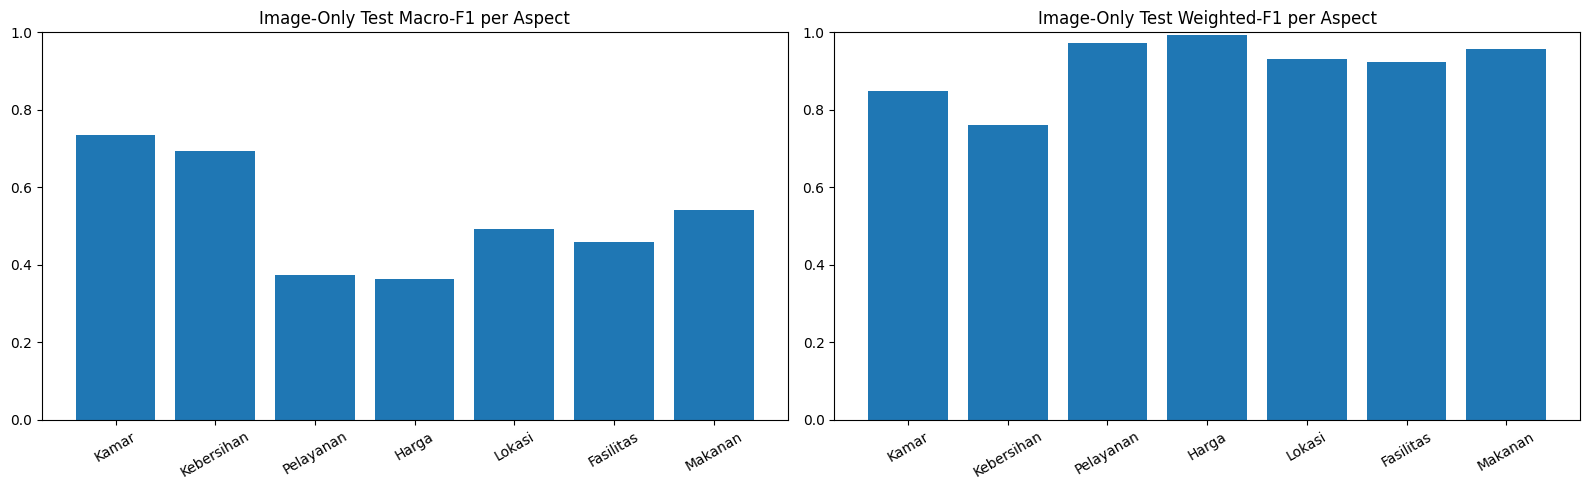

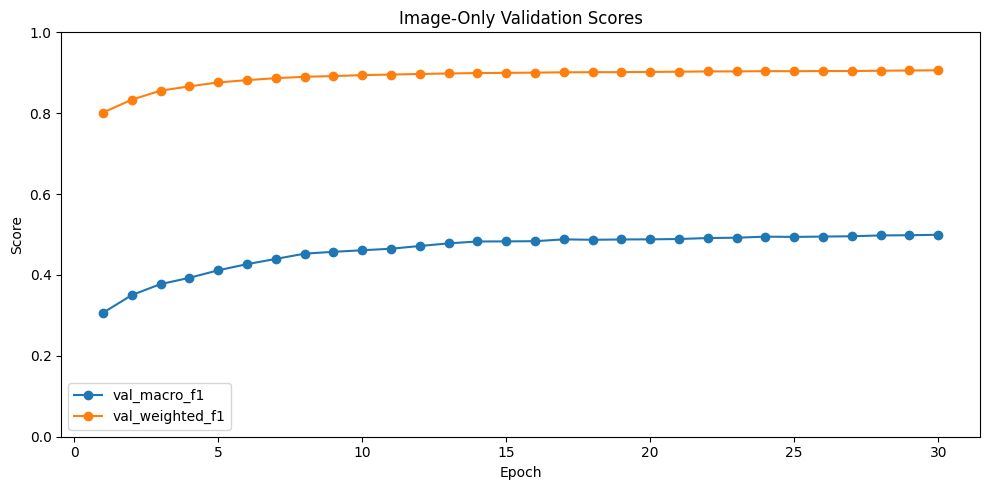

In [18]:
# Tahap: Visualisasi Metrik Evaluasi

try:
    import matplotlib.pyplot as plt

    plot_df = final_metrics_df.loc[final_metrics_df["aspect"].ne("__overall_mean__")].copy()
    test_plot = plot_df.loc[plot_df["split"].eq("test")]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].bar(test_plot["aspect"], test_plot["macro_f1"])
    axes[0].set_title("Image-Only Test Macro-F1 per Aspect")
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis="x", rotation=30)

    axes[1].bar(test_plot["aspect"], test_plot["weighted_f1"])
    axes[1].set_title("Image-Only Test Weighted-F1 per Aspect")
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

    if len(history_df):
        plt.figure(figsize=(10, 5))
        plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="val_macro_f1")
        plt.plot(history_df["epoch"], history_df["val_weighted_f1"], marker="o", label="val_weighted_f1")
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.title("Image-Only Validation Scores")
        plt.ylim(0, 1)
        plt.legend()
        plt.tight_layout()
        plt.show()
except Exception as exc:
    print("Visualisasi dilewati:", exc)

### 19. Penyimpanan Meta-Konfigurasi Eksperimen Baseline (JSON)


In [19]:
# Tahap: Penyimpanan Konfigurasi Pelatihan

training_config = {
    "seed": SEED,
    "image_model_name": IMAGE_MODEL_NAME,
    "processor_source": processor_source,
    "encoder_source": encoder_source,
    "feature_shape": list(features.shape),
    "normalize_features": NORMALIZE_FEATURES,
    "extract_batch_size": EXTRACT_BATCH_SIZE,
    "head_batch_size": HEAD_BATCH_SIZE,
    "head_epochs_configured": HEAD_EPOCHS,
    "best_epoch": int(best_epoch),
    "head_lr": HEAD_LR,
    "head_weight_decay": HEAD_WEIGHT_DECAY,
    "head_dropout": HEAD_DROPOUT,
    "head_patience": HEAD_PATIENCE,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "class_weight_power": CLASS_WEIGHT_POWER,
    "class_weight_clip_max": CLASS_WEIGHT_CLIP_MAX,
    "aspects": ASPECTS,
    "label_to_id": LABEL_TO_ID,
    "id_to_label": ID_TO_LABEL,
    "train_rows": int(train_mask.sum()),
    "val_rows": int(val_mask.sum()),
    "test_rows": int(test_mask.sum()),
    "best_val_macro_f1": float(best_val_macro_f1),
    "test_overall": test_overall,
    "target_definition": "image labels only; not text labels",
}

with open(OUTPUT_DIR / "training_config_image_only_clip.json", "w", encoding="utf-8") as f:
    json.dump(training_config, f, ensure_ascii=False, indent=2)

class_weight_table.to_csv(OUTPUT_DIR / "class_weights_used_image_only_clip.csv", index=False, encoding="utf-8-sig")

methodology_notes = f"""# Methodology Notes - Notebook 08 Image-Only Baseline ViT/CLIP

## Tujuan

Notebook 08 melatih baseline image-only memakai frozen CLIP/ViT encoder dan classifier head multi-aspect.

## Dasar Metodologi

1. CLIP mempelajari representasi visual yang transferable dari natural language supervision.
2. ViT/CLIP memakai patch-based encoding sehingga preprocessing visual harus konsisten dengan image processor pretrained.
3. Linear probing frozen encoder digunakan sebagai baseline yang stabil, hemat VRAM, dan mudah dibandingkan.
4. Target Notebook 08 adalah label image, bukan label teks.
5. Macro-F1 dipakai sebagai metric utama karena label image juga imbalanced.

## Konfigurasi

- Image model: {IMAGE_MODEL_NAME}
- Processor source: {processor_source}
- Encoder source: {encoder_source}
- Feature shape: {list(features.shape)}
- Normalize features: {NORMALIZE_FEATURES}
- Head epochs configured: {HEAD_EPOCHS}
- Best epoch: {best_epoch}
- Best validation macro-F1: {best_val_macro_f1}
- Test macro-F1: {test_overall["macro_f1"]}
- Test weighted-F1: {test_overall["weighted_f1"]}

## Catatan Interpretasi

Skor Notebook 08 mengukur kekuatan visual modality terhadap label image. Perbandingan langsung dengan Notebook 07 perlu hati-hati karena Notebook 07 memakai label teks, sedangkan Notebook 08 memakai label image.
"""

with open(OUTPUT_DIR / "methodology_notes_notebook_08.md", "w", encoding="utf-8") as f:
    f.write(methodology_notes)

print(json.dumps(training_config, ensure_ascii=False, indent=2))

{
  "seed": 42,
  "image_model_name": "openai/clip-vit-base-patch32",
  "processor_source": "openai/clip-vit-base-patch32",
  "encoder_source": "openai/clip-vit-base-patch32",
  "feature_shape": [
    13976,
    768
  ],
  "normalize_features": true,
  "extract_batch_size": 64,
  "head_batch_size": 256,
  "head_epochs_configured": 30,
  "best_epoch": 30,
  "head_lr": 0.001,
  "head_weight_decay": 0.0001,
  "head_dropout": 0.25,
  "head_patience": 5,
  "use_class_weights": true,
  "class_weight_power": 0.5,
  "class_weight_clip_max": 10.0,
  "aspects": [
    "Kamar",
    "Kebersihan",
    "Pelayanan",
    "Harga",
    "Lokasi",
    "Fasilitas",
    "Makanan"
  ],
  "label_to_id": {
    "None": 0,
    "Negatif": 1,
    "Netral": 2,
    "Positif": 3
  },
  "id_to_label": {
    "0": "None",
    "1": "Negatif",
    "2": "Netral",
    "3": "Positif"
  },
  "train_rows": 9770,
  "val_rows": 2141,
  "test_rows": 2065,
  "best_val_macro_f1": 0.49939,
  "test_overall": {
    "split": "test",
   

### 20. Verifikasi Akhir Integritas Output (Sanity Checks)


In [20]:
# Tahap: Sanity Checks (Pengecekan Integritas Data)

checks = []
checks.append({"check": "manifest_has_rows", "value": int(len(manifest) > 0), "expected": 1})
checks.append({"check": "missing_paths", "value": int(len(missing_paths)), "expected": 0})
checks.append({"check": "invalid_label_rows", "value": int(len(invalid_label_df)), "expected": 0})
checks.append({"check": "features_rows_match_manifest", "value": int(features.shape[0]), "expected": int(len(manifest))})
checks.append({"check": "labels_rows_match_manifest", "value": int(labels.shape[0]), "expected": int(len(manifest))})
checks.append({"check": "best_epoch_found", "value": int(best_epoch >= 1), "expected": 1})
checks.append({"check": "final_metrics_exists", "value": int((OUTPUT_DIR / "final_image_only_clip_metrics.csv").exists()), "expected": 1})
checks.append({"check": "test_predictions_exists", "value": int((OUTPUT_DIR / "test_predictions_image_only_clip.csv").exists()), "expected": 1})
checks.append({"check": "classification_report_exists", "value": int((OUTPUT_DIR / "classification_report_image_only_clip.csv").exists()), "expected": 1})
checks.append({"check": "checkpoint_exists", "value": int(best_head_path.exists()), "expected": 1})
checks.append({"check": "test_overall_macro_f1_valid_range", "value": int(0.0 <= float(test_overall["macro_f1"]) <= 1.0), "expected": 1})

checks_df = pd.DataFrame(checks)
checks_df["status"] = checks_df.apply(lambda row: "OK" if row["value"] == row["expected"] else "NEEDS_REVIEW", axis=1)
checks_df.to_csv(OUTPUT_DIR / "notebook_08_checks.csv", index=False, encoding="utf-8-sig")
display(checks_df)

if (checks_df["status"] == "NEEDS_REVIEW").any():
    print("Notebook 08 selesai dengan catatan. Cek baris NEEDS_REVIEW sebelum lanjut Notebook 09.")
else:
    print("Notebook 08 selesai. Image-only baseline siap dibandingkan dengan text-only dan late fusion.")

,check,value,expected,status
0,manifest_has_rows,1,1,OK
1,missing_paths,0,0,OK
2,invalid_label_rows,0,0,OK
3,features_rows_match_manifest,13976,13976,OK
4,labels_rows_match_manifest,13976,13976,OK
5,best_epoch_found,1,1,OK
6,final_metrics_exists,1,1,OK
7,test_predictions_exists,1,1,OK
8,classification_report_exists,1,1,OK
9,checkpoint_exists,1,1,OK


Notebook 08 selesai. Image-only baseline siap dibandingkan dengan text-only dan late fusion.


### 21. Kompresi dan Pengarsipan Output Hasil Eksperimen ke ZIP


In [21]:
# Tahap: Pengarsipan Output (ZIP)

zip_base = OUTPUT_DIR.parent / "mabsa_image_only_clip_baseline_outputs"
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=OUTPUT_DIR)
print("ZIP output:", zip_path)
print("\nFiles in output directory:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)

ZIP output: /kaggle/working/mabsa_image_only_clip_baseline_outputs.zip

Files in output directory:
- best_image_only_clip_head.pt
- class_weights_used_image_only_clip.csv
- classification_report_image_only_clip.csv
- clip_image_features_primary_training.npz
- confusion_matrix_image_only_clip_long.csv
- final_image_only_clip_metrics.csv
- methodology_notes_notebook_08.md
- notebook_08_checks.csv
- test_predictions_image_only_clip.csv
- training_config_image_only_clip.json
- training_history_image_only_head.csv
- val_metrics_image_only_epoch_1.csv
- val_metrics_image_only_epoch_10.csv
- val_metrics_image_only_epoch_11.csv
- val_metrics_image_only_epoch_12.csv
- val_metrics_image_only_epoch_13.csv
- val_metrics_image_only_epoch_14.csv
- val_metrics_image_only_epoch_15.csv
- val_metrics_image_only_epoch_16.csv
- val_metrics_image_only_epoch_17.csv
- val_metrics_image_only_epoch_18.csv
- val_metrics_image_only_epoch_19.csv
- val_metrics_image_only_epoch_2.csv
- val_metrics_image_only_epoch_